# Feature Engineering Exploration

This notebook is an exploration of various feature engg techniques for images, applied on the cricket data set.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import numpy as np
from skimage.feature import hog, local_binary_pattern
from scipy.spatial.distance import cdist

In [2]:
df = pd.read_csv('data/final_data/train_data.csv')

In [3]:
df.head()

,file_name,image_path,cell_number,cell_image_path,label
0,299784.webp,data/final_data/resized_images/299784.webp,58,data/final_data/grid_cells/299784/c58.jpg,no_object
1,648ff941aa8f.webp,data/final_data/resized_images/648ff941aa8f.webp,42,data/final_data/grid_cells/648ff941aa8f/c42.jpg,no_object
2,409575.webp,data/final_data/resized_images/409575.webp,39,data/final_data/grid_cells/409575/c39.jpg,no_object
3,408828.jpeg,data/final_data/resized_images/408828.jpeg,55,data/final_data/grid_cells/408828/c55.jpg,no_object
4,306975.webp,data/final_data/resized_images/306975.webp,4,data/final_data/grid_cells/306975/c04.jpg,no_object


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14335 entries, 0 to 14334
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   file_name        14335 non-null  object
 1   image_path       14335 non-null  object
 2   cell_number      14335 non-null  int64 
 3   cell_image_path  14335 non-null  object
 4   label            14335 non-null  object
dtypes: int64(1), object(4)
memory usage: 560.1+ KB


In [5]:
# load labels from data/labels.txt
with open('data/labels.txt', 'r') as f:
    labels = f.read().splitlines()
labels

['no_object', 'ball', 'bat', 'stump']

# Color Histogram Feature Extraction

This function extracts a **color histogram feature vector** from an image, which is commonly used in image classification, retrieval, and similarity comparison tasks. The histogram represents the distribution of colors in the image in a compact numerical format.

## Step-by-Step Breakdown

**Color Space Conversion**: The function first converts the input image from BGR (Blue-Green-Red) color space to HSV (Hue-Saturation-Value) using `cv2.cvtColor()`. HSV is often preferred for color-based features because it separates color information (Hue) from lighting conditions (Value), making it more robust to illumination changes than RGB/BGR.

**Histogram Calculation**: The `cv2.calcHist()` function computes a 3D histogram across all three HSV channels simultaneously. Here's what each parameter means:
- `[hsv]`: The input image wrapped in a list
- `[0,1,2]`: Use all three channels (H, S, and V)
- `None`: No mask is applied (the entire image is analyzed)
- `bins`: A tuple specifying how many bins for each channel—default `(8, 8, 8)` creates 8×8×8 = 512 bins total
- `[0,180,0,256,0,256]`: The ranges for each channel—note that Hue in OpenCV ranges from 0-180 (not 0-360), while Saturation and Value range from 0-256

**Normalization and Flattening**: The histogram is normalized (scaled to have consistent magnitude regardless of image size) and then flattened from a 3D array into a 1D feature vector. This makes it suitable for machine learning algorithms that expect fixed-length feature vectors.

## Key Gotchas

⚠️ **Hue range quirk**: OpenCV uses 0-180 for Hue instead of the standard 0-360 to fit into an 8-bit representation. This is easy to forget when working with color thresholds.

⚠️ **In-place normalization**: The line `cv2.normalize(hist, hist)` uses `hist` as both input and output, which modifies the array in place. While this saves memory, it means you can't access the original unnormalized histogram afterward.

⚠️ **High dimensionality**: With default bins of (8,8,8), you get a 512-dimensional feature vector. For larger bin counts, this can grow quickly and may require dimensionality reduction techniques.

In [6]:
def extract_color_hist(image, bins=(8, 8, 8)):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0,1,2], None, bins, [0,180,0,256,0,256])
    hist = cv2.normalize(hist, hist).flatten()
    return hist


In [168]:
def display_images_with_color_hist(images):
    """
    Display 5 images with their color histograms in a 5x2 grid.
    
    Args:
        images: List of 5 cv2 images (BGR format)
    """
    if len(images) != 5:
        raise ValueError("Function expects exactly 5 images")
    
    fig, axes = plt.subplots(5, 2, figsize=(6, 10))
    
    for i, image in enumerate(images):
        # Display the original image (convert BGR to RGB for proper display)
        axes[i, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[i, 0].set_title(f'Image {i+1}')
        axes[i, 0].axis('off')
        
        # Extract and display color histogram
        hist = extract_color_hist(image)
        axes[i, 1].bar(range(len(hist)), hist, color='steelblue', edgecolor='black', linewidth=0.5)
        axes[i, 1].set_title(f'Color Histogram {i+1}')
        axes[i, 1].set_xlabel('Bin Index')
        axes[i, 1].set_ylabel('Normalized Frequency')
        axes[i, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [169]:
def get_random_cell_images(df, n=5):
    """
    Get n random cell images ensuring at least one image per class.
    
    Args:
        df: DataFrame with 'cell_image_path' and 'label' columns
        n: Number of images to return (default: 5)
    
    Returns:
        List of cv2 images (BGR format)
    """
    # Get unique labels
    unique_labels = df['label'].unique()
    num_classes = len(unique_labels)
    
    if n < num_classes:
        raise ValueError(f"n ({n}) must be at least equal to number of classes ({num_classes})")
    
    # First, select one image from each class
    selected_indices = []
    for label in unique_labels:
        class_df = df[df['label'] == label]
        selected_idx = class_df.sample(n=1).index[0]
        selected_indices.append(selected_idx)
    
    # If we need more images, randomly select from remaining rows
    remaining_count = n - num_classes
    if remaining_count > 0:
        remaining_df = df.drop(selected_indices)
        additional_indices = remaining_df.sample(n=remaining_count).index.tolist()
        selected_indices.extend(additional_indices)
    
    # Load the images
    images = []
    for idx in selected_indices:
        image_path = df.loc[idx, 'cell_image_path']
        image = cv2.imread(image_path)
        images.append(image)
    
    return images

In [170]:
def get_random_images_by_label(df, label, n=5):
    """
    Get n random cell images from a specific label/class.
    
    Args:
        df: DataFrame with 'cell_image_path' and 'label' columns
        label: The label/class to select images from
        n: Number of images to return (default: 5)
    
    Returns:
        List of cv2 images (BGR format)
    """
    # Filter dataframe for the specified label
    label_df = df[df['label'] == label]
    
    if len(label_df) == 0:
        raise ValueError(f"No images found for label '{label}'")
    
    if len(label_df) < n:
        raise ValueError(f"Only {len(label_df)} images available for label '{label}', but {n} requested")
    
    # Randomly select n images from this label
    selected_rows = label_df.sample(n=n)
    
    # Load the images
    images = []
    for idx, row in selected_rows.iterrows():
        image_path = row['cell_image_path']
        image = cv2.imread(image_path)
        images.append(image)
    
    return images

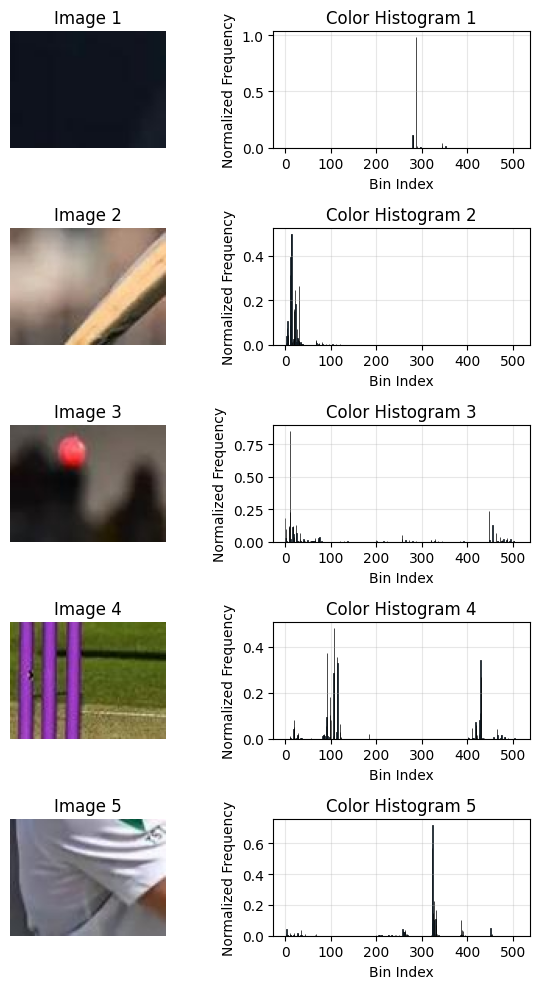

In [171]:
images = get_random_cell_images(df, n=5)
display_images_with_color_hist(images)

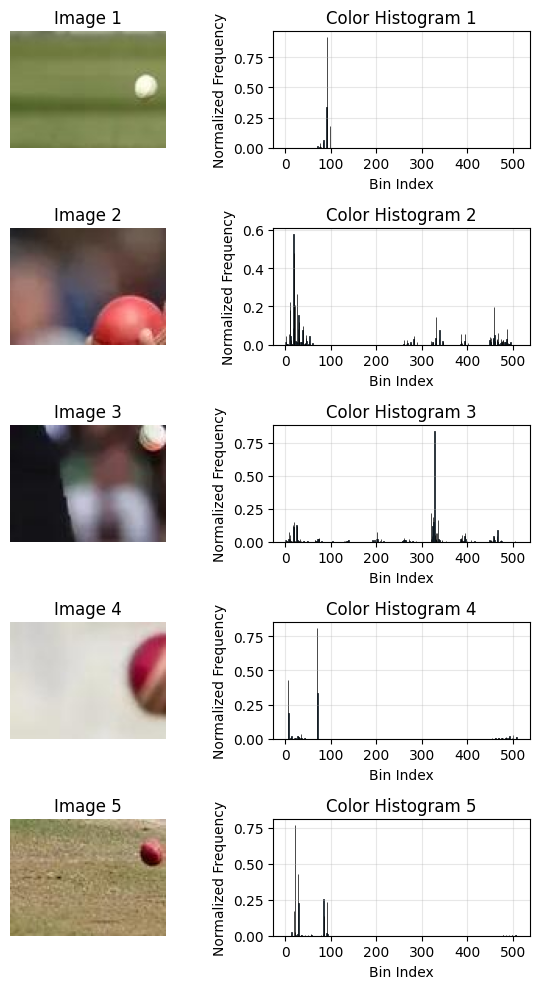

In [172]:
ball_images = get_random_images_by_label(df, label='ball', n=5)
display_images_with_color_hist(ball_images)

# Local Binary Pattern (LBP) Feature Extraction

This function extracts **Local Binary Pattern (LBP) features** from an image, which is a powerful texture descriptor widely used in computer vision tasks like texture classification, face recognition, and object detection. LBP captures local texture patterns by comparing each pixel with its surrounding neighbors.

## Step-by-Step Breakdown

**Grayscale Conversion**: The function first converts the BGR color image to grayscale using `cv2.cvtColor()`. LBP operates on intensity values rather than colors, so this conversion is necessary. Texture patterns are generally more evident in intensity variations than color differences.

**LBP Computation**: The `local_binary_pattern()` function from scikit-image computes the LBP representation. With the default parameters (`n_points=8`, `radius=1`), it examines 8 neighboring pixels arranged in a circle of radius 1 around each pixel. For each neighbor, it assigns a binary value (0 or 1) based on whether the neighbor's intensity is greater than or equal to the center pixel's intensity. These 8 binary values are then combined to create a decimal number (0-255 for 8 neighbors). The `'uniform'` method specifically looks for uniform patterns—those with at most 2 bitwise transitions (like 00000000 or 00011110)—which are rotation-invariant and capture fundamental texture primitives.

**Histogram Creation**: The LBP image is flattened using `.ravel()` and then converted into a histogram using `np.histogram()`. The bin configuration `bins=np.arange(0, n_points+3)` with `range=(0, n_points+2)` creates bins for uniform patterns. For the default 8 neighbors with uniform method, this produces 10 bins: 9 bins for the different rotation-invariant uniform patterns, plus 1 bin for all non-uniform patterns. This dramatically reduces dimensionality compared to using all 256 possible LBP values.

**Normalization**: The histogram is converted to float type and normalized by dividing by its sum (with a tiny epsilon `1e-6` added to prevent division by zero). This makes the feature vector scale-invariant—images of different sizes or with different numbers of pixels will produce comparable histograms. The result is essentially a probability distribution over the different texture patterns present in the image.

## Key Gotchas

⚠️ **Uniform vs. Non-uniform**: The `'uniform'` method collapses 256 possible LBP codes into just 59 rotation-invariant uniform patterns (for 8 neighbors). All non-uniform patterns are grouped into a single bin. This is great for dimensionality reduction but loses some texture detail. If you need finer texture discrimination, consider using `method='default'`.

⚠️ **Bin count calculation**: The expression `n_points+3` for bins might seem odd. For uniform LBP with 8 points, there are exactly $n\_points + 2 = 10$ distinct uniform patterns (including the non-uniform catchall). The `+3` creates 11 bin edges to define 10 bins when using `np.arange()` and the specified range.

⚠️ **Epsilon in normalization**: The `1e-6` prevents division by zero for completely black images (where all histogram bins would be zero). Without it, you'd get NaN values that would break downstream machine learning models.

⚠️ **Loss of spatial information**: LBP histograms capture texture patterns but completely discard spatial layout. Two images with identical textures in different arrangements will produce the same feature vector. For applications where spatial structure matters, consider dividing the image into regions and computing LBP histograms for each region separately.

In [7]:
def extract_lbp(image, radius=1, n_points=8, method='uniform'):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, n_points, radius, method)
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, n_points+3),
                             range=(0, n_points+2))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)
    return hist

In [174]:
def display_images_with_lbp(images):
    """
    Display 5 images with their LBP histograms in a 5x2 grid.
    
    Args:
        images: List of 5 cv2 images (BGR format)
    """
    if len(images) != 5:
        raise ValueError("Function expects exactly 5 images")
    
    fig, axes = plt.subplots(5, 2, figsize=(6, 10))
    
    for i, image in enumerate(images):
        # Display the original image (convert BGR to RGB for proper display)
        axes[i, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[i, 0].set_title(f'Image {i+1}')
        axes[i, 0].axis('off')
        
        # Extract and display LBP histogram
        lbp_hist = extract_lbp(image)
        axes[i, 1].bar(range(len(lbp_hist)), lbp_hist, color='coral', edgecolor='black', linewidth=0.5)
        axes[i, 1].set_title(f'LBP Histogram {i+1}')
        axes[i, 1].set_xlabel('Pattern Index')
        axes[i, 1].set_ylabel('Normalized Frequency')
        axes[i, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

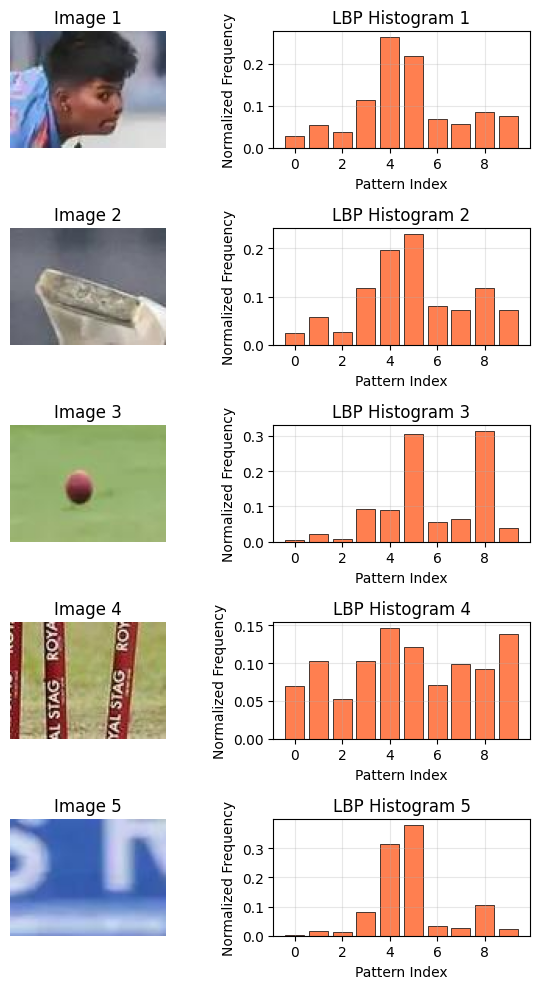

In [175]:
images = get_random_cell_images(df, n=5)
display_images_with_lbp(images)

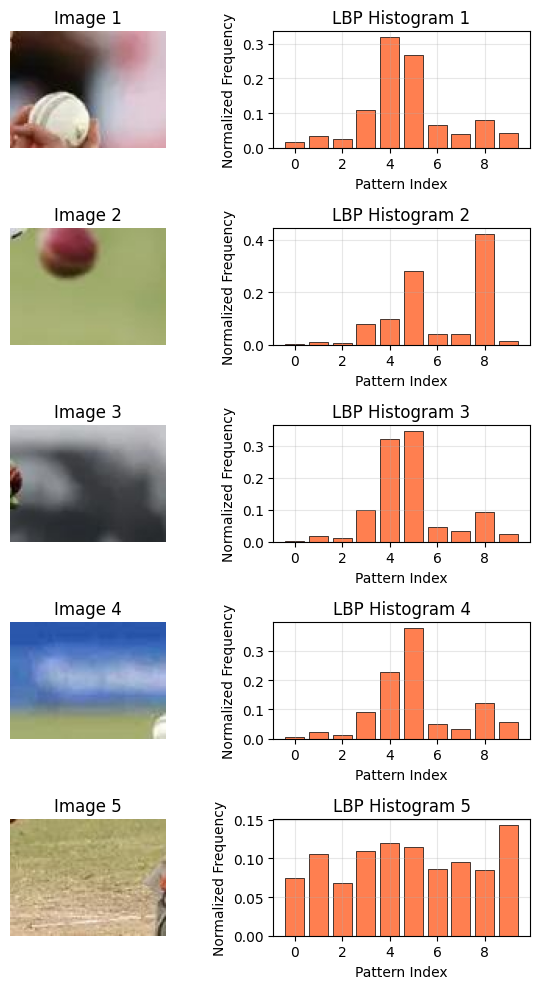

In [176]:
ball_images = get_random_images_by_label(df, label='ball', n=5)
display_images_with_lbp(ball_images)

# Histogram of Oriented Gradients (HOG) Feature Extraction

This function extracts **Histogram of Oriented Gradients (HOG) features** from an image, which is one of the most effective shape and edge descriptors in computer vision. HOG features are particularly powerful for object detection and recognition tasks, famously used in pedestrian detection systems and image classification pipelines.

## Step-by-Step Breakdown

**Grayscale Conversion**: The function begins by converting the BGR color image to grayscale using `cv2.cvtColor()`. HOG works on gradient information (changes in intensity), which is best captured in grayscale. Since gradients represent edges and contours regardless of color, operating on intensity values is both more efficient and effective.

**HOG Computation**: The `hog()` function from scikit-image performs a multi-stage computation to extract gradient-based features:

- **Orientations (9 bins)**: The gradient directions are quantized into 9 orientation bins spanning 0° to 180°. This means each gradient is categorized into one of 9 angular ranges, creating a histogram of "which directions do edges point in this region?"

- **Pixels per Cell (8×8)**: The image is divided into small 8×8 pixel cells. Within each cell, a histogram of gradient orientations is computed by accumulating gradient magnitudes into the 9 orientation bins. This spatial grouping captures local shape information while maintaining some tolerance to small positional variations.

- **Cells per Block (2×2)**: Cells are further grouped into 2×2 blocks (covering 16×16 pixels). Each block overlaps with neighboring blocks, creating a sliding window effect. This redundancy helps capture features at slightly different positions and improves robustness.

- **Block Normalization (L2-Hys)**: Within each block, the histogram values are normalized using the L2-Hys method. This involves L2 normalization (dividing by the Euclidean norm), clipping values to a maximum of 0.2 (the "Hys" or hysteresis step), and re-normalizing. This sophisticated normalization scheme provides strong invariance to lighting changes and shadows—a bright edge and a dim edge with the same orientation will produce similar feature values.

- **Transform Sqrt (True)**: Before computing gradients, the square root of pixel intensities is applied (gamma correction). This power-law compression reduces the influence of shadows and illumination variations by making dark regions relatively brighter, helping the algorithm focus on shape rather than absolute brightness.

- **Feature Vector (True)**: The resulting multi-dimensional array is flattened into a 1D feature vector, making it ready for machine learning algorithms. The final vector size depends on image dimensions but is typically several thousand features for a standard image.

## Key Gotchas

⚠️ **High dimensional output**: HOG produces very long feature vectors. For an image with many cells and blocks, you might get 3000+ features. This can lead to computational overhead and potential overfitting if your dataset is small. Consider dimensionality reduction techniques like PCA if needed.

⚠️ **Image size sensitivity**: The number of features depends on image dimensions. If you're processing images of varying sizes, you'll get inconsistent feature vector lengths, which breaks most ML algorithms. Always resize images to a fixed size before HOG extraction.

⚠️ **Transform_sqrt caveat**: The `transform_sqrt=True` parameter applies square root compression, which **only works with non-negative pixel values**. If you've preprocessed your images with normalization that introduces negative values, this will raise an error.

⚠️ **Overlapping blocks create redundancy**: Because blocks overlap (a 2×2 block slides by 1 cell at a time), each cell's histogram appears in multiple blocks with different normalizations. This redundancy increases the feature vector size significantly but improves discriminative power—it's a deliberate trade-off for better performance.

⚠️ **Loss of color information**: By converting to grayscale, you discard color information entirely. For applications where color is important (like distinguishing a red apple from a green apple with similar shapes), consider combining HOG with color-based features like the color histogram you've already implemented.

In [8]:
def extract_hog(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    hog_features = hog(gray, orientations=9, pixels_per_cell=(8,8),
                       cells_per_block=(2,2), block_norm='L2-Hys',
                       transform_sqrt=True, feature_vector=True)
    return hog_features

In [178]:
def display_images_with_hog(images):
    """
    Display 5 images with their HOG feature histograms in a 5x2 grid.
    
    Args:
        images: List of 5 cv2 images (BGR format)
    """
    if len(images) != 5:
        raise ValueError("Function expects exactly 5 images")
    
    fig, axes = plt.subplots(5, 2, figsize=(6, 10))
    
    for i, image in enumerate(images):
        # Display the original image (convert BGR to RGB for proper display)
        axes[i, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[i, 0].set_title(f'Image {i+1}')
        axes[i, 0].axis('off')
        
        # Extract and display HOG features
        hog_features = extract_hog(image)
        axes[i, 1].plot(hog_features, color='green', linewidth=0.5)
        axes[i, 1].set_title(f'HOG Features {i+1}')
        axes[i, 1].set_xlabel('Feature Index')
        axes[i, 1].set_ylabel('Feature Value')
        axes[i, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

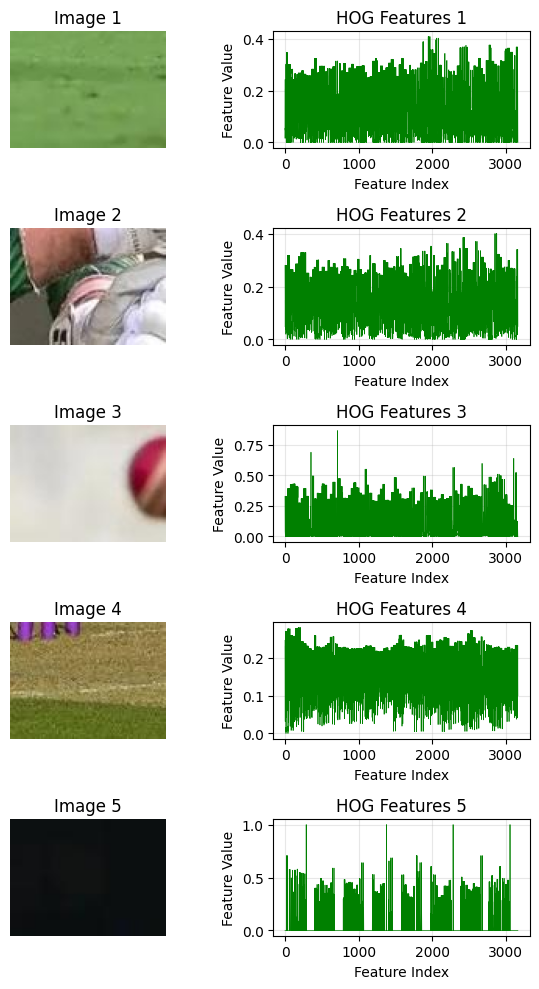

In [179]:
images = get_random_cell_images(df, n=5)
display_images_with_hog(images)

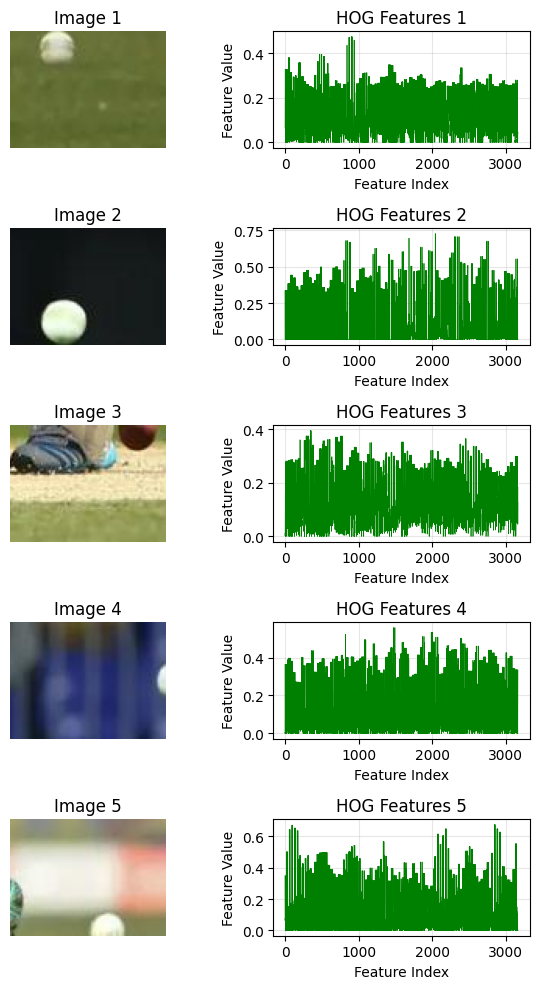

In [180]:
ball_images = get_random_images_by_label(df, label='ball', n=5)
display_images_with_hog(ball_images)

In [9]:
def extract_color_moments_hsv(image):
    """
    Compute color moments (mean, std, skewness) for each HSV channel.
    
    Returns:
        A 9-dimensional feature vector:
        [mean_H, std_H, skew_H,
         mean_S, std_S, skew_S,
         mean_V, std_V, skew_V]
    """

    # Convert BGR → HSV (OpenCV loads images in BGR)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV).astype(np.float32)

    H, S, V = cv2.split(hsv)
    channels = [H, S, V]

    features = []

    for ch in channels:
        mean = np.mean(ch)
        std = np.std(ch)

        # Avoid division by zero in skewness calculation
        eps = 1e-6
        skew = np.mean(((ch - mean) / (std + eps)) ** 3)

        features.extend([mean, std, skew])

    return np.array(features, dtype=np.float32)

In [182]:
def display_images_with_color_moments(images):
    """
    Display 5 images with their color moments in a 5x2 grid.
    
    Args:
        images: List of 5 cv2 images (BGR format)
    """
    if len(images) != 5:
        raise ValueError("Function expects exactly 5 images")
    
    fig, axes = plt.subplots(5, 2, figsize=(8, 10))
    
    for i, image in enumerate(images):
        # Display the original image (convert BGR to RGB for proper display)
        axes[i, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[i, 0].set_title(f'Image {i+1}')
        axes[i, 0].axis('off')
        
        # Extract color moments
        moments = extract_color_moments_hsv(image)
        
        # Create a grouped bar chart for the 9 features
        # 3 moments (mean, std, skew) for each of 3 channels (H, S, V)
        x = np.arange(3)  # 3 channels
        width = 0.25
        
        means = moments[0::3]  # [mean_H, mean_S, mean_V]
        stds = moments[1::3]   # [std_H, std_S, std_V]
        skews = moments[2::3]  # [skew_H, skew_S, skew_V]
        
        axes[i, 1].bar(x - width, means, width, label='Mean', color='skyblue', edgecolor='black')
        axes[i, 1].bar(x, stds, width, label='Std Dev', color='lightcoral', edgecolor='black')
        axes[i, 1].bar(x + width, skews, width, label='Skewness', color='lightgreen', edgecolor='black')
        
        axes[i, 1].set_title(f'Color Moments {i+1}')
        axes[i, 1].set_xlabel('Channel')
        axes[i, 1].set_ylabel('Value')
        axes[i, 1].set_xticks(x)
        axes[i, 1].set_xticklabels(['H', 'S', 'V'])
        axes[i, 1].legend(fontsize=8)
        axes[i, 1].grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

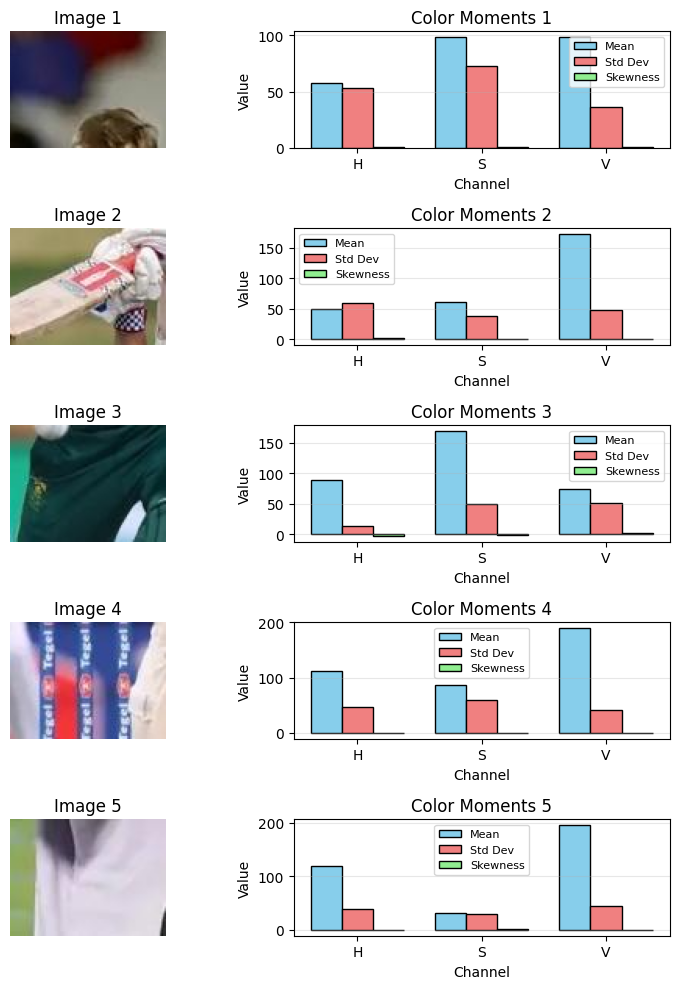

In [183]:
images = get_random_cell_images(df, n=5)
display_images_with_color_moments(images)

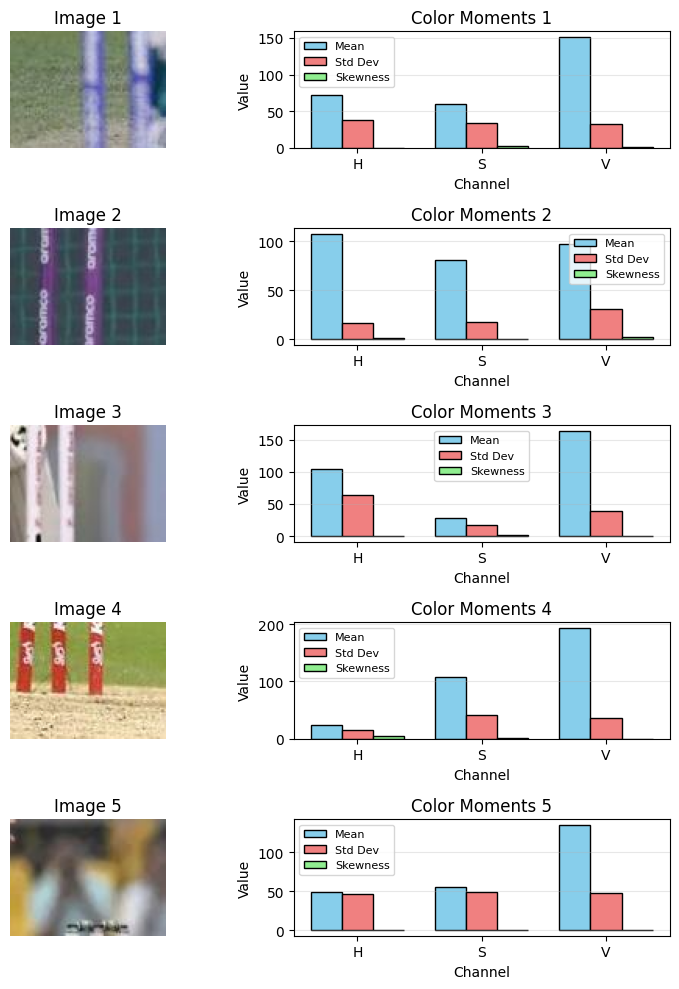

In [184]:
ball_images = get_random_images_by_label(df, label='stump', n=5)
display_images_with_color_moments(ball_images)

In [10]:
def extract_color_correlogram(image, h_bins=8, s_bins=3, v_bins=3,
                              distances=[1, 3, 5]):
    """
    Compute a color correlogram for an HSV image.

    Args:
        image: BGR image (OpenCV format)
        h_bins, s_bins, v_bins: quantization bins for HSV channels
        distances: list of pixel distances to consider
        
    Returns:
        1D numpy array = flattened correlogram feature vector
    """

    # Convert to HSV
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV).astype(np.float32)

    H, S, V = cv2.split(hsv)
    h_max, s_max, v_max = 180.0, 256.0, 256.0

    # Quantize to color bins (create 3D bin index for each pixel)
    Hq = np.floor(H / (h_max / h_bins)).astype(np.int32)
    Sq = np.floor(S / (s_max / s_bins)).astype(np.int32)
    Vq = np.floor(V / (v_max / v_bins)).astype(np.int32)

    # Clip to avoid edge cases
    Hq = np.clip(Hq, 0, h_bins - 1)
    Sq = np.clip(Sq, 0, s_bins - 1)
    Vq = np.clip(Vq, 0, v_bins - 1)

    # Combined bin index per pixel (0 to N-1)
    total_bins = h_bins * s_bins * v_bins
    bins = (Hq * s_bins * v_bins) + (Sq * v_bins) + Vq

    # Precompute coordinates of all pixels
    h, w = bins.shape
    coords = np.indices((h, w)).reshape(2, -1).T   # shape: (H*W, 2)
    flat_bins = bins.flatten()                     # shape: (H*W,)

    # Pairwise pixel distances (too heavy for large images, 
    # but fine for 100×75 = 7500 pixels)
    D = cdist(coords, coords, metric='euclidean')  # (HW × HW)

    # Prepare correlogram array
    correlogram = np.zeros((len(distances), total_bins), dtype=np.float32)

    # Compute correlogram
    for di, dist in enumerate(distances):
        # mask of pixel pairs at ~this distance (±0.5 tolerance)
        mask = np.abs(D - dist) < 0.5

        # For each pixel, look at neighbors at distance dist
        row_bins = flat_bins.reshape(-1, 1)
        col_bins = flat_bins.reshape(1, -1)

        # color matches at this distance
        matches = mask & (row_bins == col_bins)

        # Count matches per color bin
        for cb in range(total_bins):
            correlogram[di, cb] = np.sum(matches[flat_bins == cb])

        # Normalize (avoid division by zero)
        correlogram[di] /= (np.sum(mask) + 1e-6)

    # Flatten feature vector
    return correlogram.flatten()


In [186]:
def display_images_with_correlogram(images):
    """
    Display 5 images with their color correlograms in a 5x2 grid.
    
    Args:
        images: List of 5 cv2 images (BGR format)
    """
    if len(images) != 5:
        raise ValueError("Function expects exactly 5 images")
    
    fig, axes = plt.subplots(5, 2, figsize=(8, 10))
    
    for i, image in enumerate(images):
        # Display the original image (convert BGR to RGB for proper display)
        axes[i, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[i, 0].set_title(f'Image {i+1}')
        axes[i, 0].axis('off')
        
        # Extract color correlogram
        correlogram = extract_color_correlogram(image)
        
        # Reshape to show distance × color bins structure
        # Default: 3 distances × (8*3*3) = 72 color bins = 3×72 matrix
        num_distances = 3
        num_color_bins = len(correlogram) // num_distances
        correlogram_matrix = correlogram.reshape(num_distances, num_color_bins)
        
        # Display as heatmap
        im = axes[i, 1].imshow(correlogram_matrix, aspect='auto', cmap='viridis', interpolation='nearest')
        axes[i, 1].set_title(f'Correlogram {i+1}')
        axes[i, 1].set_xlabel('Color Bin Index')
        axes[i, 1].set_ylabel('Distance')
        axes[i, 1].set_yticks(range(num_distances))
        axes[i, 1].set_yticklabels(['d=1', 'd=3', 'd=5'])
        
        # Add colorbar for the heatmap
        plt.colorbar(im, ax=axes[i, 1], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

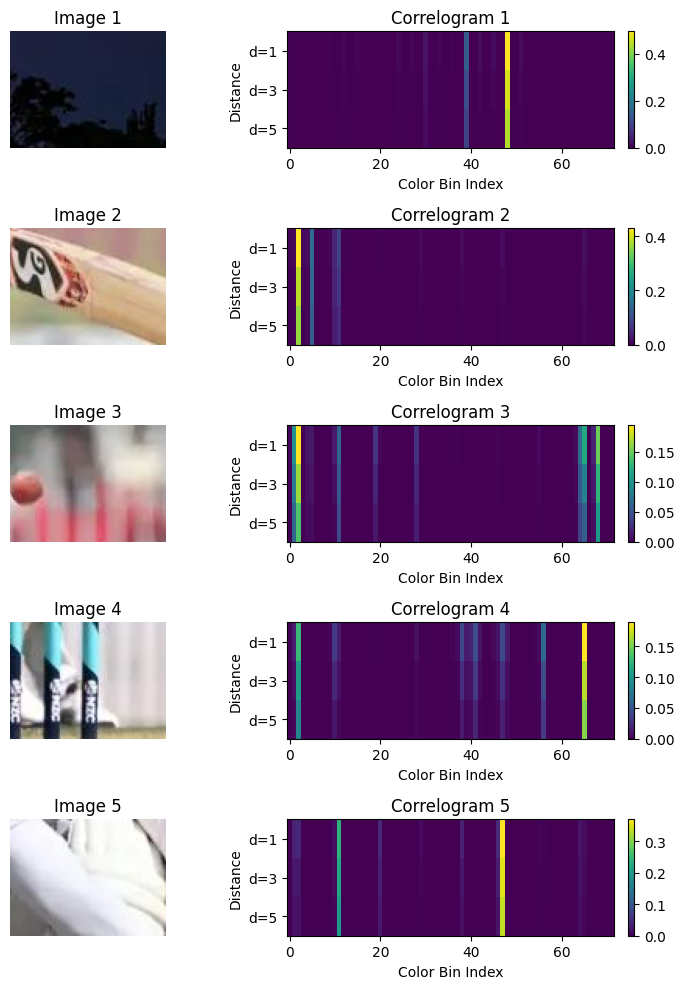

In [187]:
images = get_random_cell_images(df, n=5)
display_images_with_correlogram(images)

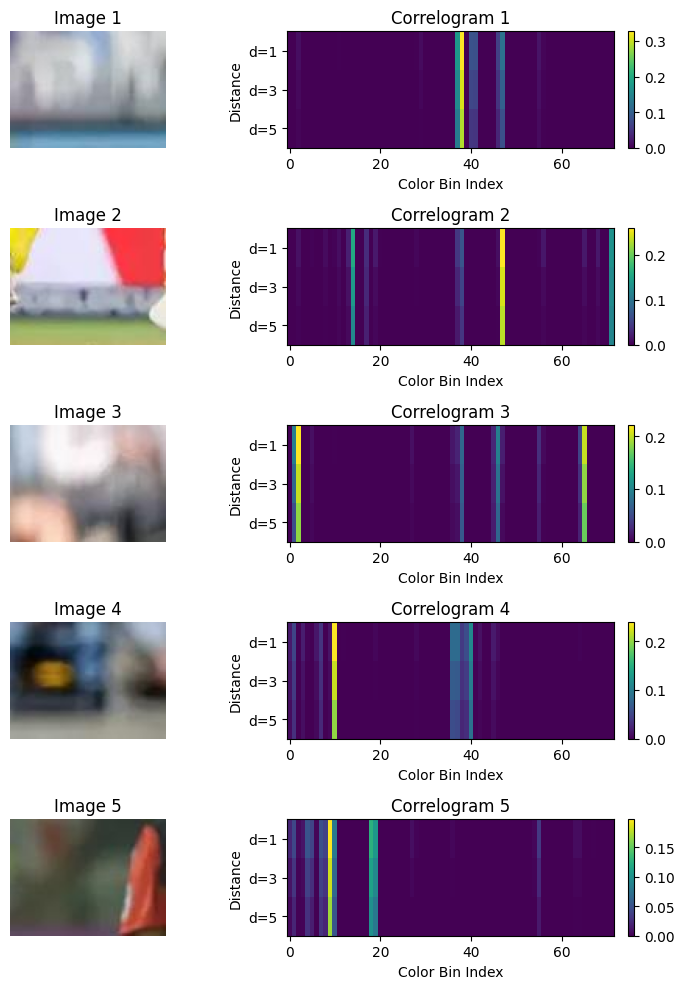

In [188]:
ball_images = get_random_images_by_label(df, label='no_object')
display_images_with_correlogram(ball_images)

In [11]:
def extract_gabor_features(image,
                           ksize=31,
                           wavelengths=(4.0, 8.0, 16.0),
                           orientations=(0, 45, 90, 135),
                           sigma=None,
                           gamma=0.5,
                           psi=0,
                           borderType=cv2.BORDER_REPLICATE):
    """
    Extract Gabor filter-bank features from an image.

    Args:
        image: input image in BGR or grayscale (np.uint8 or float).
        ksize: size of the Gabor kernel (odd integer). Default 31.
        wavelengths: iterable of wavelengths (lambda) for Gabor (in pixels).
        orientations: iterable of orientations in degrees.
        sigma: gaussian sigma; if None, sigma = 0.56 * lambda (common heuristic).
        gamma: spatial aspect ratio (default 0.5).
        psi: phase offset (default 0).
        borderType: cv2 border type for filtering.

    Returns:
        1D numpy array of features with dtype float32.
        For each (wavelength, orientation) pair, the returned statistics are:
            [mean_response, std_response, energy_response]
        So total feature length = 3 * (len(wavelengths) * len(orientations)).
    """

    # Convert to grayscale if needed and ensure float32
    if image.ndim == 3 and image.shape[2] == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY).astype(np.float32)
    else:
        gray = image.astype(np.float32)

    # Normalize intensity to zero mean / unit variance (optional but helps)
    gray_mean = gray.mean()
    gray_std = gray.std() + 1e-6
    gray = (gray - gray_mean) / gray_std

    feats = []

    # Precompute orientations in radians
    thetas = [np.deg2rad(t) for t in orientations]

    for lam in wavelengths:
        # choose sigma relative to wavelength if not provided
        sigma_used = sigma if sigma is not None else 0.56 * lam

        # OpenCV expects ksize as tuple (ksize, ksize)
        ksize_adj = (ksize, ksize)

        for theta in thetas:
            # OpenCV's getGaborKernel uses parameters:
            # ksize, sigma, theta, lambda, gamma, psi, ktype
            kernel = cv2.getGaborKernel(ksize_adj, sigma_used, theta, lam, gamma, psi, ktype=cv2.CV_32F)

            # Normalize kernel to zero mean (optional, helps stability)
            kernel = kernel - kernel.mean()

            # Filter image
            filtered = cv2.filter2D(gray, cv2.CV_32F, kernel, borderType=borderType)

            # Compute summary statistics for this filter response
            mean_resp = float(filtered.mean())
            std_resp = float(filtered.std())
            energy_resp = float(np.sum(filtered ** 2))  # energy

            feats.extend([mean_resp, std_resp, energy_resp])

    return np.asarray(feats, dtype=np.float32)


In [190]:
def display_images_with_gabor(images):
    """
    Display 5 images with their Gabor filter features in a 5x2 grid.
    
    Args:
        images: List of 5 cv2 images (BGR format)
    """
    if len(images) != 5:
        raise ValueError("Function expects exactly 5 images")
    
    fig, axes = plt.subplots(5, 2, figsize=(10, 10))
    
    for i, image in enumerate(images):
        # Display the original image (convert BGR to RGB for proper display)
        axes[i, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[i, 0].set_title(f'Image {i+1}')
        axes[i, 0].axis('off')
        
        # Extract Gabor features
        gabor_features = extract_gabor_features(image)
        
        # Reshape for visualization: 3 statistics per (wavelength, orientation) combo
        # Default: 3 wavelengths × 4 orientations = 12 combos × 3 stats = 36 features
        num_combos = len(gabor_features) // 3
        gabor_matrix = gabor_features.reshape(num_combos, 3)
        
        # Display as heatmap
        im = axes[i, 1].imshow(gabor_matrix.T, aspect='auto', cmap='coolwarm', interpolation='nearest')
        axes[i, 1].set_title(f'Gabor Features {i+1}')
        axes[i, 1].set_xlabel('Filter Index (λ × θ)')
        axes[i, 1].set_ylabel('Statistic')
        axes[i, 1].set_yticks(range(3))
        axes[i, 1].set_yticklabels(['Mean', 'Std', 'Energy'])
        
        # Add colorbar for the heatmap
        plt.colorbar(im, ax=axes[i, 1], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

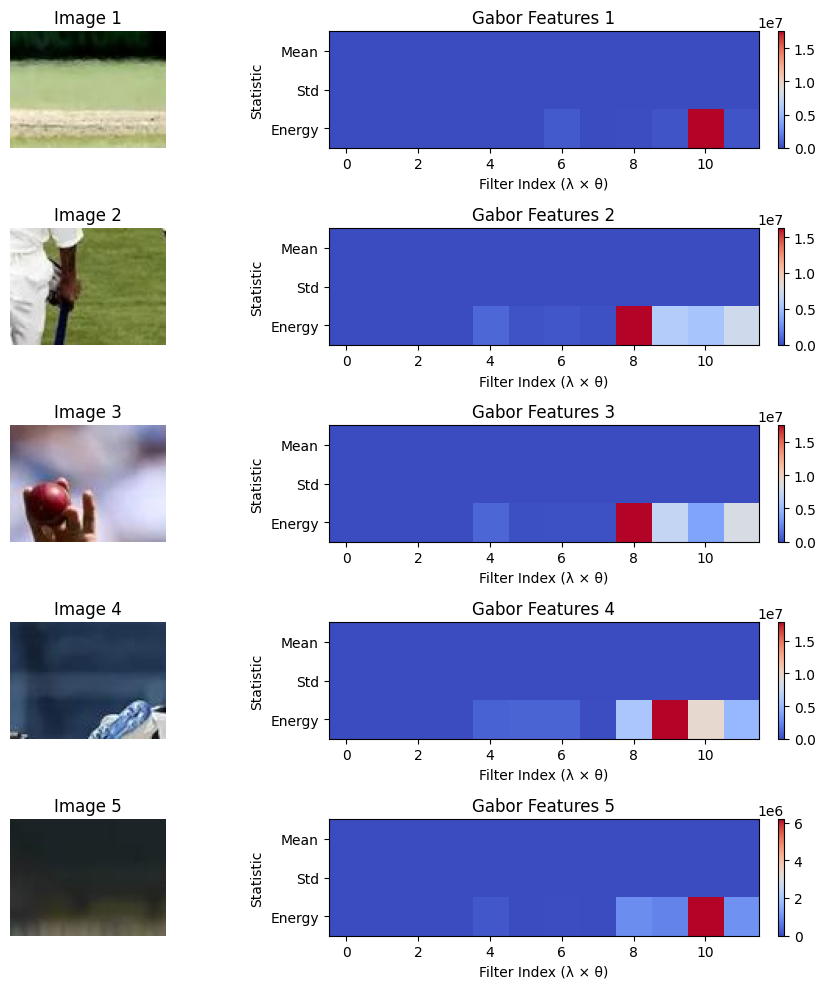

In [191]:
images = get_random_cell_images(df, n=5)
display_images_with_gabor(images)

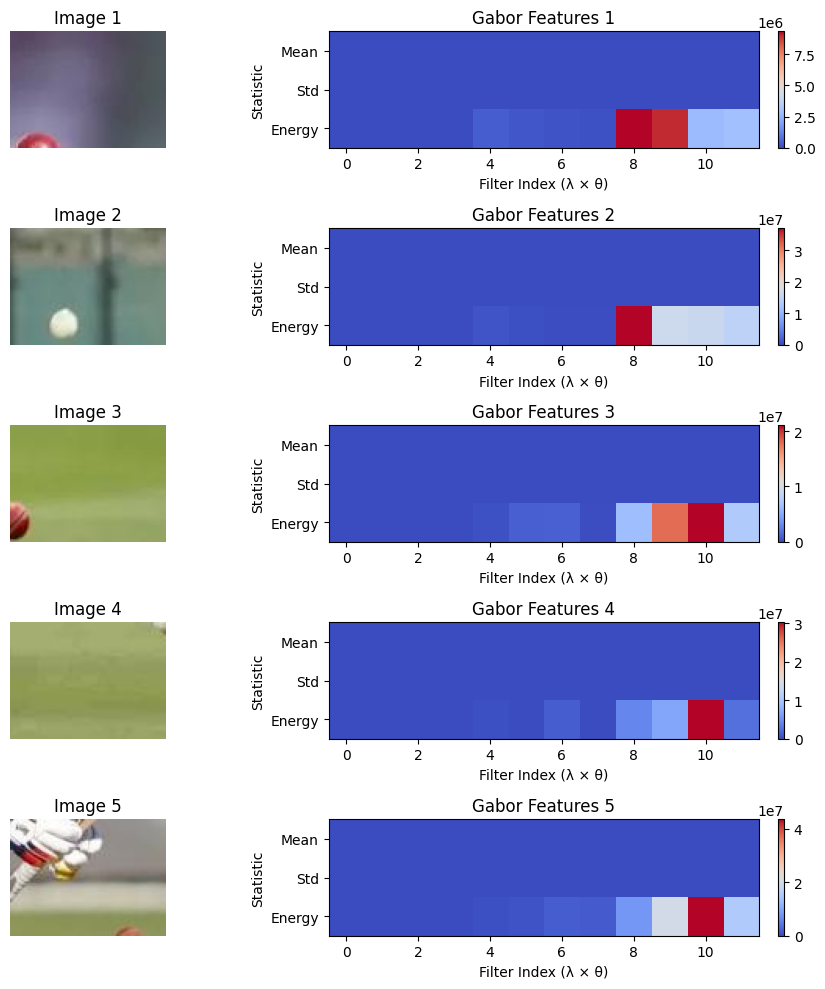

In [192]:
ball_images = get_random_images_by_label(df, label='ball', n=5)
display_images_with_gabor(ball_images)

In [12]:
def extract_edge_outline_features(image,
                                  canny_sigma=0.33,
                                  sobel_ksize=3,
                                  orientation_bins=16,
                                  min_contour_area=10):
    """
    Extract edge- and outline-focused features from an image.

    Returns a 1D numpy array of floats with the following components (in order):
      1) edge_density                 -> fraction of pixels detected as edges
      2) mean_edge_strength           -> mean gradient magnitude over edge pixels
      3) median_edge_strength         -> median gradient magnitude over edge pixels
      4) orientation_hist (orientation_bins values) -> histogram of edge orientations (L2-normalized)
      5) n_contours                   -> number of contours found (clipped / scaled)
      6) mean_contour_area            -> mean contour area (normalized by image area)
      7) largest_contour_area_ratio   -> largest contour area / image area
      8) mean_contour_perimeter      -> mean contour perimeter (normalized by image diagonal)
      9) largest_contour_perimeter   -> perimeter of largest contour (normalized)
     10) solidity_of_largest         -> solidity (area / convex_hull_area) of largest contour
     11) extent_of_largest          -> bounding_box_area / contour_area (<=1)
     12) circularity_of_largest     -> 4*pi*area / (perimeter^2) (0..1 for perfect circle)
     13) hu_moments (7 values)      -> log-transformed absolute Hu moments of largest contour

    Args:
        image: input image (BGR or grayscale) as numpy array (uint8 or float).
        canny_sigma: parameter for automatic Canny thresholds (ratio to median gradient).
        sobel_ksize: kernel size for computing gradients (1,3,5,...).
        orientation_bins: number of bins for edge orientation histogram.
        min_contour_area: ignore contours smaller than this (in pixels).

    Returns:
        features: 1D numpy array (dtype=np.float32)
    """

    # --- Prepare grayscale image ---
    if image.ndim == 3 and image.shape[2] == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()
    if gray.dtype != np.uint8:
        gray = (255 * (gray.astype(np.float32) - gray.min()) / (gray.ptp() + 1e-9)).astype(np.uint8)

    h, w = gray.shape
    img_area = float(h * w)
    img_diag = float(np.sqrt(h*h + w*w))

    # --- Compute gradients (Sobel) and gradient magnitude / orientation ---
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=sobel_ksize)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=sobel_ksize)
    mag = np.sqrt(gx*gx + gy*gy)
    orient = (np.arctan2(gy, gx) + np.pi)  # range [0, 2π)

    # --- Canny edges with automatic thresholds based on median ---
    # auto thresholds: lower = max(0, (1 - sigma) * median), upper = min(255, (1 + sigma) * median)
    med = np.median(gray)
    lower = int(max(0, (1.0 - canny_sigma) * med))
    upper = int(min(255, (1.0 + canny_sigma) * med))
    edges = cv2.Canny(gray, threshold1=lower, threshold2=upper)

    # Edge mask
    edge_mask = edges > 0
    n_edge_pixels = int(edge_mask.sum())
    edge_density = n_edge_pixels / (img_area + 1e-9)

    # Edge strength stats
    if n_edge_pixels > 0:
        edge_mags = mag[edge_mask]
        mean_edge_strength = float(edge_mags.mean())
        median_edge_strength = float(np.median(edge_mags))
    else:
        mean_edge_strength = 0.0
        median_edge_strength = 0.0

    # --- Orientation histogram computed only on edge pixels, weighted by magnitude ---
    # Bin orientations from 0..2pi into orientation_bins
    ori_hist = np.zeros(orientation_bins, dtype=np.float32)
    if n_edge_pixels > 0:
        # Map orientations to bin indices
        bin_idx = np.floor((orient[edge_mask] / (2 * np.pi)) * orientation_bins).astype(int)
        bin_idx = np.clip(bin_idx, 0, orientation_bins - 1)
        # Weighted histogram by magnitude
        for b, m in zip(bin_idx, edge_mags):
            ori_hist[b] += float(m)
        # L2-normalize histogram (stability for concatenation)
        norm = np.linalg.norm(ori_hist) + 1e-9
        ori_hist = ori_hist / norm
    else:
        # keep zeros

        pass

    # --- Contour extraction from a dilated edge map (helps connect broken edges) ---
    # Dilate edges slightly to join broken outlines
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    edges_dilated = cv2.dilate(edges, kernel, iterations=1)

    contours, _ = cv2.findContours(edges_dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Filter tiny contours
    filtered_contours = []
    areas = []
    perimeters = []
    for cnt in contours:
        a = cv2.contourArea(cnt)
        if a >= min_contour_area:
            filtered_contours.append(cnt)
            areas.append(a)
            perimeters.append(cv2.arcLength(cnt, True))

    n_contours = len(filtered_contours)

    # statistics normalized
    if n_contours > 0:
        mean_contour_area = float(np.mean(areas) / (img_area + 1e-9))
        largest_area = float(max(areas))
        largest_idx = int(np.argmax(areas))
        mean_contour_perimeter = float(np.mean(perimeters) / (img_diag + 1e-9))
        largest_perimeter = float(perimeters[largest_idx] / (img_diag + 1e-9))
    else:
        mean_contour_area = 0.0
        largest_area = 0.0
        mean_contour_perimeter = 0.0
        largest_perimeter = 0.0

    largest_contour_area_ratio = largest_area / (img_area + 1e-9)

    # --- Shape descriptors for largest contour (if exists) ---
    solidity = 0.0
    extent = 0.0
    circularity = 0.0
    hu_feats = np.zeros(7, dtype=np.float32)

    if n_contours > 0:
        largest_cnt = filtered_contours[largest_idx]
        # Convex hull area for solidity
        hull = cv2.convexHull(largest_cnt)
        hull_area = cv2.contourArea(hull)
        cnt_area = cv2.contourArea(largest_cnt)
        if hull_area > 1e-6:
            solidity = float(cnt_area / hull_area)
        else:
            solidity = 0.0

        # Extent = contour_area / bounding_box_area
        x, y, bw, bh = cv2.boundingRect(largest_cnt)
        bbox_area = float(bw * bh) + 1e-9
        extent = float(cnt_area / bbox_area)

        # Circularity = 4*pi*area / perimeter^2
        perim = cv2.arcLength(largest_cnt, True)
        if perim > 1e-6:
            circularity = float(4.0 * np.pi * cnt_area / (perim * perim))
        else:
            circularity = 0.0

        # Hu moments (7) from contour moments, take log transform for stability
        moments = cv2.moments(largest_cnt)
        hu = cv2.HuMoments(moments).flatten()  # 7 values
        # convert to log scale and absolute to reduce dynamic range
        for i in range(7):
            v = hu[i]
            if v == 0:
                hu_feats[i] = 0.0
            else:
                hu_feats[i] = float(-np.sign(v) * np.log10(abs(v) + 1e-30))

    # --- Assemble final feature vector ---
    features = [
        edge_density,
        mean_edge_strength,
        median_edge_strength,
    ]
    features.extend(ori_hist.tolist())
    # Contour statistics: we scale n_contours by a smooth function to keep values bounded
    # (e.g., n_contours / (n_contours + 10)) to avoid huge numbers when many tiny contours exist.
    contours_count_scaled = float(n_contours / (n_contours + 10.0))
    features.extend([
        contours_count_scaled,
        mean_contour_area,
        largest_contour_area_ratio,
        mean_contour_perimeter,
        largest_perimeter,
        solidity,
        extent,
        circularity
    ])
    features.extend(hu_feats.tolist())

    return np.asarray(features, dtype=np.float32)


In [194]:
def display_images_with_edge_outline(images):
    """
    Display 5 images with their edge-outline features in a 5x2 grid.
    
    Args:
        images: List of 5 cv2 images (BGR format)
    """
    if len(images) != 5:
        raise ValueError("Function expects exactly 5 images")
    
    fig, axes = plt.subplots(5, 2, figsize=(10, 12))
    
    for i, image in enumerate(images):
        # Display the original image (convert BGR to RGB for proper display)
        axes[i, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[i, 0].set_title(f'Image {i+1}')
        axes[i, 0].axis('off')
        
        # Extract edge-outline features
        edge_features = extract_edge_outline_features(image)
        
        # Group features for better visualization
        # Structure: [edge_density, mean_edge, median_edge, 
        #             orientation_hist(16), n_contours, mean_area, largest_area,
        #             mean_perim, largest_perim, solidity, extent, circularity, hu(7)]
        feature_groups = {
            'Edge Stats': edge_features[0:3],  # density, mean, median
            'Orientation (16)': edge_features[3:19],  # orientation histogram
            'Contour Stats': edge_features[19:28],  # contour features
            'Hu Moments': edge_features[28:35]  # 7 Hu moments
        }
        
        # Create grouped bar chart
        ax = axes[i, 1]
        positions = []
        labels = []
        values = []
        colors = []
        color_map = {'Edge Stats': 'steelblue', 'Orientation (16)': 'coral', 
                     'Contour Stats': 'lightgreen', 'Hu Moments': 'gold'}
        
        pos = 0
        for group_name, group_values in feature_groups.items():
            for j, val in enumerate(group_values):
                positions.append(pos)
                labels.append(f'{group_name[:4]}{j}')
                values.append(val)
                colors.append(color_map[group_name])
                pos += 1
            pos += 0.5  # gap between groups
        
        ax.bar(positions, values, color=colors, edgecolor='black', linewidth=0.5)
        ax.set_title(f'Edge-Outline Features {i+1}')
        ax.set_xlabel('Feature Index')
        ax.set_ylabel('Value')
        ax.grid(alpha=0.3, axis='y')
        
        # Add legend
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=color_map[name], label=name) 
                          for name in feature_groups.keys()]
        ax.legend(handles=legend_elements, fontsize=7, loc='upper right')
    
    plt.tight_layout()
    plt.show()

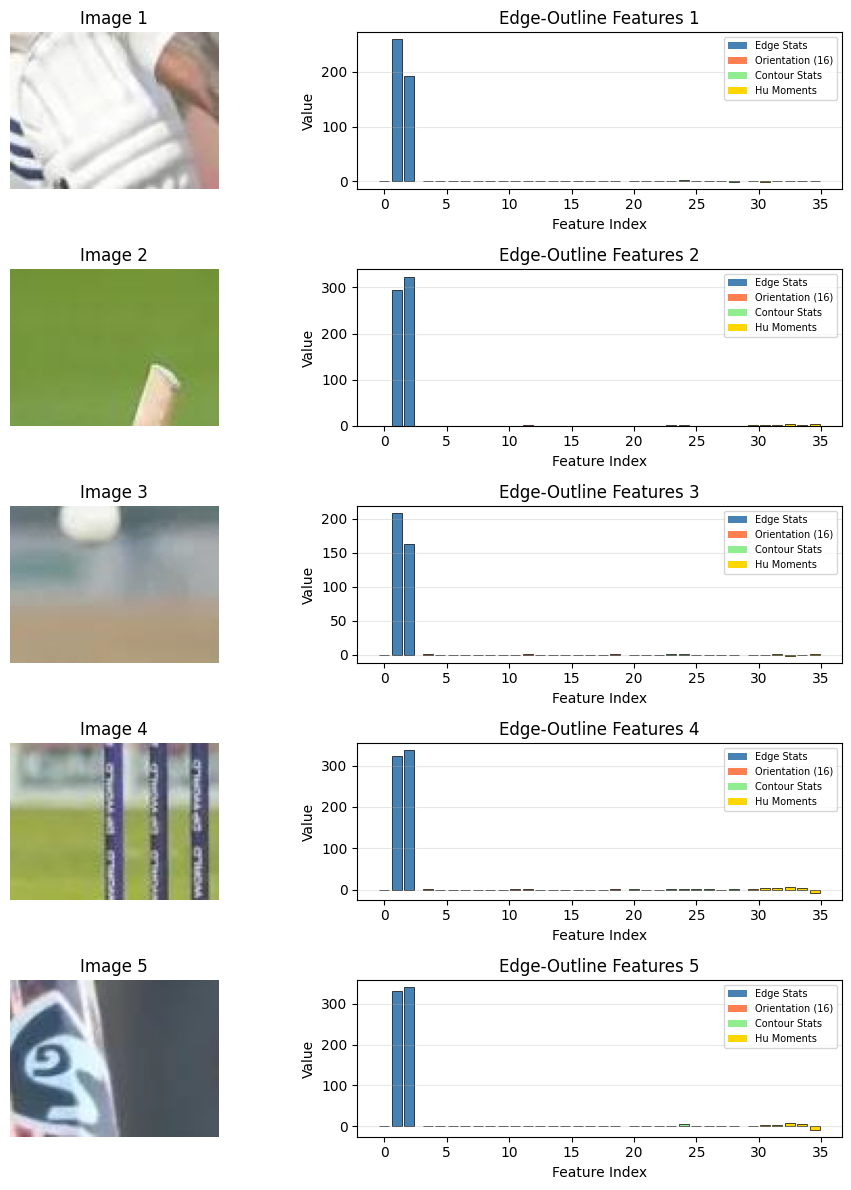

In [195]:
images = get_random_cell_images(df, n=5)
display_images_with_edge_outline(images)

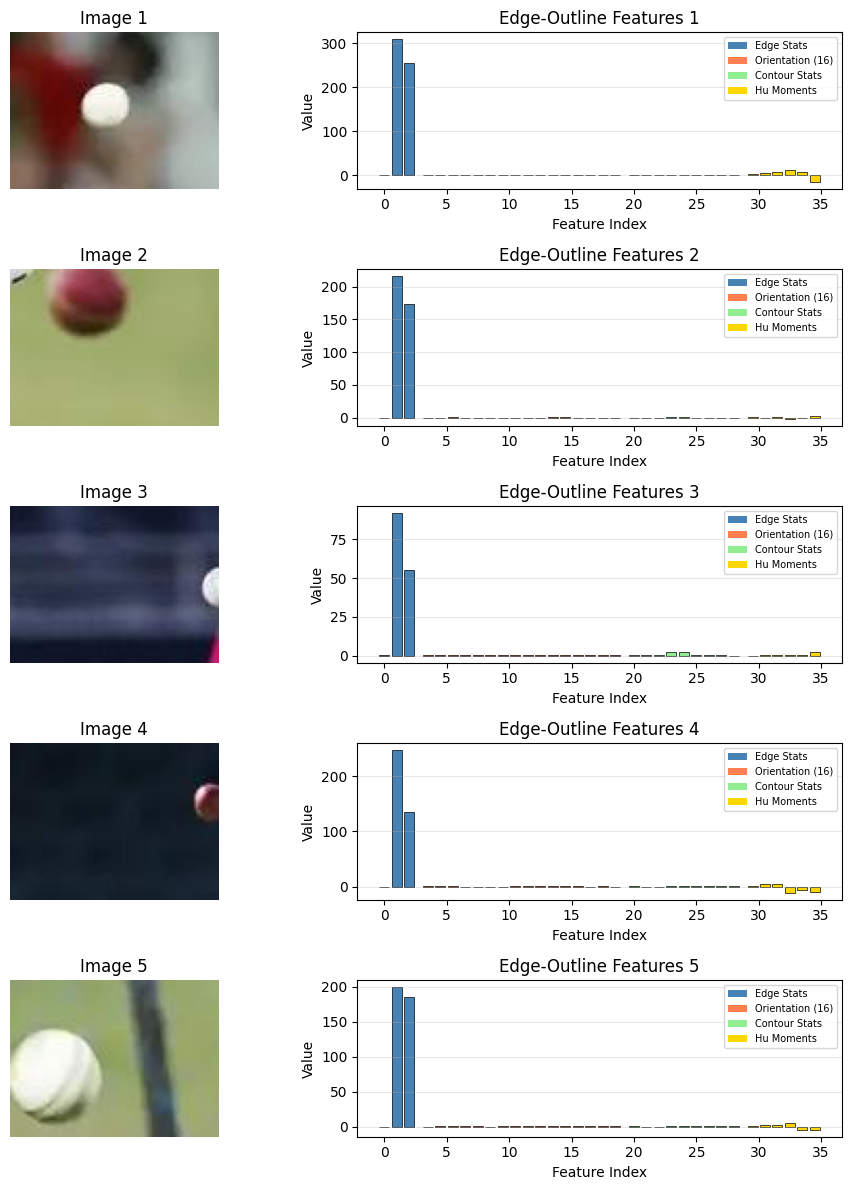

In [196]:
ball_images = get_random_images_by_label(df, label='ball', n=5)
display_images_with_edge_outline(ball_images)

In [13]:
def _ring_kernel(dist):
    """
    Build a small ring-shaped convolution kernel for distance = dist.
    The kernel contains ones at pixels whose Euclidean distance is
    approximately dist (±0.5), zeros elsewhere.
    Size = (2*dist+1, 2*dist+1).
    """
    size = 2 * dist + 1
    y, x = np.ogrid[-dist:dist+1, -dist:dist+1]
    r = np.sqrt(x*x + y*y)
    mask = (np.abs(r - dist) <= 0.5).astype(np.float32)
    return mask


def extract_auto_correlogram(image,
                             h_bins=8, s_bins=3, v_bins=3,
                             distances=[1, 3, 5]):
    """
    Fast Auto-Correlogram in HSV color space.
    Counts how often a pixel of a given quantized color has
    neighbors of the *same color* at distances in `distances`.

    Args:
        image: BGR image (OpenCV)
        h_bins, s_bins, v_bins: quantization levels
        distances: list of radii for autocorrelogram shells

    Returns:
        1D numpy array of length: len(distances) * (h_bins * s_bins * v_bins)
    """

    # --- Convert to HSV ---
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV).astype(np.float32)
    H, S, V = hsv[:,:,0], hsv[:,:,1], hsv[:,:,2]

    # --- Quantize channels ---
    Hq = np.floor(H / (180.0 / h_bins)).astype(np.int32)
    Sq = np.floor(S / (256.0 / s_bins)).astype(np.int32)
    Vq = np.floor(V / (256.0 / v_bins)).astype(np.int32)

    Hq = np.clip(Hq, 0, h_bins - 1)
    Sq = np.clip(Sq, 0, s_bins - 1)
    Vq = np.clip(Vq, 0, v_bins - 1)

    # Combined bin index (0 .. total_bins-1)
    total_bins = h_bins * s_bins * v_bins
    bins = (Hq * s_bins * v_bins) + (Sq * v_bins) + Vq

    h, w = bins.shape
    img_area = h * w

    # Create binary masks for each quantized color bin
    # Each mask is shape (h, w), dtype float32
    bin_masks = []
    for cb in range(total_bins):
        bin_masks.append((bins == cb).astype(np.float32))

    # Output: correlogram[di, cb]
    correlogram = np.zeros((len(distances), total_bins), dtype=np.float32)

    # For each distance, convolve using a ring kernel
    for di, dist in enumerate(distances):
        ring = _ring_kernel(dist)

        for cb in range(total_bins):

            mask = bin_masks[cb]

            cnt_center = mask.sum()  # number of pixels of this color

            if cnt_center == 0:
                correlogram[di, cb] = 0.0
                continue

            # Convolution: count same-color neighbors at radius dist
            # mask ⊗ ring
            neigh = cv2.filter2D(mask, cv2.CV_32F, ring, borderType=cv2.BORDER_CONSTANT)

            # For auto-correlogram, we only count instances where center AND neighbor are same color
            # i.e., sum over: mask * neigh
            total_matches = float((neigh * mask).sum())

            # Normalize by number of center pixels (or by img_area; both common)
            correlogram[di, cb] = total_matches / (cnt_center + 1e-6)

    return correlogram.flatten().astype(np.float32)


In [14]:
def extract_features(image):
    f2 = extract_lbp(image)
    f3 = extract_hog(image)
    f4 = extract_auto_correlogram(image)
    f5 = extract_gabor_features(image)
    f6 = extract_edge_outline_features(image)
    f7 = extract_color_moments_hsv(image)
    fv = np.hstack([f2, f3, f4, f5, f6, f7])

    # downcast to float32
    fv = fv.astype(np.float32)
    return fv

In [15]:
df_features = df

In [16]:
from tqdm import tqdm

# Extract features for each cell image and store in a new column
feature_vectors = []

for idx, row in tqdm(df_features.iterrows(), total=len(df_features), desc="Extracting features"):
    # Load the cell image
    image = cv2.imread(row['cell_image_path'])
    
    # Extract features
    features = extract_features(image)
    feature_vectors.append(features)

# Add the feature vectors as a new column
df_features['feature_vector'] = feature_vectors

Extracting features:   0%|          | 0/14335 [00:00<?, ?it/s]

Extracting features: 100%|██████████| 14335/14335 [04:49<00:00, 49.47it/s]


In [17]:
df_features.head(100)

,file_name,image_path,cell_number,cell_image_path,label,feature_vector
0,299784.webp,data/final_data/resized_images/299784.webp,58,data/final_data/grid_cells/299784/c58.jpg,no_object,"[0.0025333334, 0.025066666, 0.0072, 0.08773333..."
1,648ff941aa8f.webp,data/final_data/resized_images/648ff941aa8f.webp,42,data/final_data/grid_cells/648ff941aa8f/c42.jpg,no_object,"[0.0033333334, 0.022933334, 0.0152, 0.1232, 0...."
2,409575.webp,data/final_data/resized_images/409575.webp,39,data/final_data/grid_cells/409575/c39.jpg,no_object,"[0.00093333336, 0.011333333, 0.008133333, 0.10..."
3,408828.jpeg,data/final_data/resized_images/408828.jpeg,55,data/final_data/grid_cells/408828/c55.jpg,no_object,"[0.0018666667, 0.016533334, 0.0049333335, 0.08..."
4,306975.webp,data/final_data/resized_images/306975.webp,4,data/final_data/grid_cells/306975/c04.jpg,no_object,"[0.00053333334, 0.0076, 0.0010666667, 0.081066..."
...,...,...,...,...,...,...
95,308860.webp,data/final_data/resized_images/308860.webp,60,data/final_data/grid_cells/308860/c60.jpg,no_object,"[0.07613333, 0.09773333, 0.071333334, 0.106666..."
96,83e24127dd74.webp,data/final_data/resized_images/83e24127dd74.webp,10,data/final_data/grid_cells/83e24127dd74/c10.jpg,bat,"[0.0070666666, 0.024266666, 0.019066667, 0.149..."
97,409892.webp,data/final_data/resized_images/409892.webp,42,data/final_data/grid_cells/409892/c42.jpg,no_object,"[0.0077333334, 0.029066667, 0.016133333, 0.115..."
98,308843.webp,data/final_data/resized_images/308843.webp,2,data/final_data/grid_cells/308843/c02.jpg,no_object,"[0.014266667, 0.045066666, 0.039066665, 0.1433..."


In [18]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14335 entries, 0 to 14334
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   file_name        14335 non-null  object
 1   image_path       14335 non-null  object
 2   cell_number      14335 non-null  int64 
 3   cell_image_path  14335 non-null  object
 4   label            14335 non-null  object
 5   feature_vector   14335 non-null  object
dtypes: int64(1), object(5)
memory usage: 672.1+ KB


In [19]:
df_features['feature_vector'].iloc[0].shape

(3473,)

In [20]:
FEATURE_COUNT = df_features['feature_vector'].iloc[0].shape[0]
FEATURE_COUNT

3473

In [21]:
# Create a new Dataframe with feature vectors expanded into separate columns and the label column
# Feature columns will be named f0, f1, f2, ..., fn upto FEATURE_COUNT
fv = pd.DataFrame(df_features['feature_vector'].tolist())
fv.columns = [f'f{i}' for i in range(FEATURE_COUNT)]
fv['label'] = df_features['label']
fv['image_path'] = df_features['image_path']
fv['cell_number'] = df_features['cell_number']
fv['cell_image_path'] = df_features['cell_image_path']
fv.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f3467,f3468,f3469,f3470,f3471,f3472,label,image_path,cell_number,cell_image_path
0,0.002533,0.025067,0.007200,0.087733,0.114267,0.360533,0.070933,0.053333,0.233733,0.044667,...,91.806000,12.529564,-0.218953,201.730927,9.080140,-1.050871,no_object,data/final_data/resized_images/299784.webp,58,data/final_data/grid_cells/299784/c58.jpg
1,0.003333,0.022933,0.015200,0.123200,0.386933,0.302400,0.054000,0.026400,0.041467,0.024133,...,68.478798,43.146996,1.002107,85.109467,30.384699,0.210047,no_object,data/final_data/resized_images/648ff941aa8f.webp,42,data/final_data/grid_cells/648ff941aa8f/c42.jpg
2,0.000933,0.011333,0.008133,0.106133,0.301200,0.320933,0.041200,0.033733,0.162267,0.014133,...,136.542267,71.812653,0.147966,197.526932,6.737097,-0.371850,no_object,data/final_data/resized_images/409575.webp,39,data/final_data/grid_cells/409575/c39.jpg
3,0.001867,0.016533,0.004933,0.082667,0.303600,0.398533,0.033467,0.021600,0.108133,0.028667,...,57.380001,12.993029,-1.470382,173.228531,61.692570,-0.751049,no_object,data/final_data/resized_images/408828.jpeg,55,data/final_data/grid_cells/408828/c55.jpg
4,0.000533,0.007600,0.001067,0.081067,0.014133,0.282400,0.034933,0.058800,0.508400,0.011067,...,193.431198,4.218049,0.029969,106.227730,1.987395,-0.120476,no_object,data/final_data/resized_images/306975.webp,4,data/final_data/grid_cells/306975/c04.jpg


In [22]:
fv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14335 entries, 0 to 14334
Columns: 3477 entries, f0 to cell_image_path
dtypes: float32(3473), int64(1), object(3)
memory usage: 190.4+ MB


In [23]:
fv.to_csv('data/final_data/train_data_with_features.csv', index=False)

In [24]:
# Load the validation dataset and extract features similarly
df_val = pd.read_csv('data/final_data/val_data.csv')
df_val.head()

,file_name,image_path,cell_number,cell_image_path,label
0,d441f6b5a4d3.webp,data/final_data/resized_images/d441f6b5a4d3.webp,38,data/final_data/grid_cells/d441f6b5a4d3/c38.jpg,no_object
1,408878.jpeg,data/final_data/resized_images/408878.jpeg,29,data/final_data/grid_cells/408878/c29.jpg,no_object
2,e93408ad04b7.webp,data/final_data/resized_images/e93408ad04b7.webp,49,data/final_data/grid_cells/e93408ad04b7/c49.jpg,no_object
3,410080.jpeg,data/final_data/resized_images/410080.jpeg,25,data/final_data/grid_cells/410080/c25.jpg,no_object
4,325833.webp,data/final_data/resized_images/325833.webp,32,data/final_data/grid_cells/325833/c32.jpg,no_object


In [25]:
from tqdm import tqdm

# Extract features for each cell image and store in a new column
feature_vectors = []

for idx, row in tqdm(df_val.iterrows(), total=len(df_val), desc="Extracting features"):
    # Load the cell image
    image = cv2.imread(row['cell_image_path'])
    
    # Extract features
    features = extract_features(image)
    feature_vectors.append(features)

# Add the feature vectors as a new column
df_val['feature_vector'] = feature_vectors

Extracting features: 100%|██████████| 3073/3073 [02:36<00:00, 19.60it/s]


In [26]:
# Create a new Dataframe with feature vectors expanded into separate columns and the label column
# Feature columns will be named f0, f1, f2, ..., fn upto FEATURE_COUNT
fv_val = pd.DataFrame(df_val['feature_vector'].tolist())
fv_val.columns = [f'f{i}' for i in range(FEATURE_COUNT)]
fv_val['label'] = df_val['label']
fv_val['image_path'] = df_val['image_path']
fv_val['cell_number'] = df_val['cell_number']
fv_val['cell_image_path'] = df_val['cell_image_path']
fv_val.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f3467,f3468,f3469,f3470,f3471,f3472,label,image_path,cell_number,cell_image_path
0,0.003067,0.015467,0.015867,0.125733,0.423867,0.259867,0.045733,0.024133,0.067200,0.019067,...,94.996536,68.619911,0.537277,108.106003,58.497112,0.339263,no_object,data/final_data/resized_images/d441f6b5a4d3.webp,38,data/final_data/grid_cells/d441f6b5a4d3/c38.jpg
1,0.000800,0.009600,0.002933,0.079200,0.044133,0.283200,0.049600,0.057467,0.456667,0.016400,...,109.232269,8.214616,-0.276156,133.083862,2.751491,-1.071715,no_object,data/final_data/resized_images/408878.jpeg,29,data/final_data/grid_cells/408878/c29.jpg
2,0.001067,0.010400,0.003600,0.066267,0.123467,0.317333,0.029200,0.024667,0.406400,0.017600,...,145.606674,30.780678,-2.203600,193.941864,25.979469,-1.388489,no_object,data/final_data/resized_images/e93408ad04b7.webp,49,data/final_data/grid_cells/e93408ad04b7/c49.jpg
3,0.001600,0.017200,0.009067,0.093467,0.206800,0.315200,0.060667,0.044400,0.226267,0.025333,...,144.857727,49.928734,-0.019239,42.710133,30.851227,0.638330,no_object,data/final_data/resized_images/410080.jpeg,25,data/final_data/grid_cells/410080/c25.jpg
4,0.004267,0.024133,0.024133,0.140400,0.453733,0.236267,0.040400,0.022400,0.032800,0.021467,...,69.727867,53.090363,0.849767,130.704529,64.693359,-0.191891,no_object,data/final_data/resized_images/325833.webp,32,data/final_data/grid_cells/325833/c32.jpg


In [27]:
fv_val.to_csv('data/final_data/val_data_with_features.csv', index=False)

In [28]:
# Load the test dataset and extract features similarly
df_test = pd.read_csv('data/final_data/test_data.csv')
df_test.head()

,file_name,image_path,cell_number,cell_image_path,label
0,409179.webp,data/final_data/resized_images/409179.webp,1,data/final_data/grid_cells/409179/c01.jpg,no_object
1,409179.webp,data/final_data/resized_images/409179.webp,2,data/final_data/grid_cells/409179/c02.jpg,no_object
2,409179.webp,data/final_data/resized_images/409179.webp,3,data/final_data/grid_cells/409179/c03.jpg,no_object
3,409179.webp,data/final_data/resized_images/409179.webp,4,data/final_data/grid_cells/409179/c04.jpg,no_object
4,409179.webp,data/final_data/resized_images/409179.webp,5,data/final_data/grid_cells/409179/c05.jpg,no_object


In [29]:
from tqdm import tqdm

# Extract features for each cell image and store in a new column
feature_vectors = []

for idx, row in tqdm(df_test.iterrows(), total=len(df_test), desc="Extracting features"):
    # Load the cell image
    image = cv2.imread(row['cell_image_path'])
    
    # Extract features
    features = extract_features(image)
    feature_vectors.append(features)

# Add the feature vectors as a new column
df_test['feature_vector'] = feature_vectors

Extracting features: 100%|██████████| 3072/3072 [02:25<00:00, 21.15it/s]


In [30]:
# Create a new Dataframe with feature vectors expanded into separate columns and the label column
# Feature columns will be named f0, f1, f2, ..., fn upto FEATURE_COUNT
fv_test = pd.DataFrame(df_test['feature_vector'].tolist())
fv_test.columns = [f'f{i}' for i in range(FEATURE_COUNT)]
fv_test['label'] = df_test['label']
fv_test['image_path'] = df_test['image_path']
fv_test['cell_number'] = df_test['cell_number']
fv_test['cell_image_path'] = df_test['cell_image_path']
fv_test.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f3467,f3468,f3469,f3470,f3471,f3472,label,image_path,cell_number,cell_image_path
0,0.000000,0.000000,0.000000,0.006133,0.000000,0.095067,0.000533,0.001867,0.896400,0.000000,...,80.707069,11.464504,-1.038173,18.878134,1.792972,1.240822,no_object,data/final_data/resized_images/409179.webp,1,data/final_data/grid_cells/409179/c01.jpg
1,0.000000,0.000000,0.000000,0.004267,0.000000,0.082933,0.000267,0.001600,0.910933,0.000000,...,81.826668,9.560856,0.368170,17.981867,1.113525,0.488826,no_object,data/final_data/resized_images/409179.webp,2,data/final_data/grid_cells/409179/c02.jpg
2,0.004533,0.005733,0.003733,0.007067,0.006667,0.067067,0.005600,0.006800,0.885200,0.007600,...,88.097466,11.704641,1.643247,22.658934,22.479038,7.123489,no_object,data/final_data/resized_images/409179.webp,3,data/final_data/grid_cells/409179/c03.jpg
3,0.031733,0.034267,0.022267,0.032267,0.035600,0.090400,0.030267,0.044267,0.617200,0.061733,...,78.716530,28.472025,-0.247865,35.595467,36.529835,2.610824,no_object,data/final_data/resized_images/409179.webp,4,data/final_data/grid_cells/409179/c04.jpg
4,0.000000,0.000000,0.000000,0.001067,0.000000,0.046400,0.000000,0.000000,0.952533,0.000000,...,89.806396,2.440188,2.566694,20.105600,0.307325,2.566635,no_object,data/final_data/resized_images/409179.webp,5,data/final_data/grid_cells/409179/c05.jpg


In [31]:
fv_test.to_csv('data/final_data/test_data_with_features.csv', index=False)